# EDA Solar Power Generation Data

Notebook nay chi thuc hien khai pha du lieu, tien xu li va ghep noi du lieu o cap plant/timestamp. Notebook khong huan luyen mo hinh.

## 1. Khoi tao moi truong

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datasets'
API_WEATHER_DIR = DATA_DIR / 'api_weather'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANTS = [1, 2]

## 2. Ham tien xu li dung chung

In [2]:
def resolve_dataset_path(filename: str) -> Path:
    dataset_path = DATA_DIR / filename
    if dataset_path.exists():
        return dataset_path
    fallback_path = BASE_DIR / filename
    if fallback_path.exists():
        return fallback_path
    raise FileNotFoundError(f'Khong tim thay dataset: {filename}')


def parse_generation_datetime(series: pd.Series, plant_no: int) -> pd.Series:
    if plant_no == 1:
        return pd.to_datetime(series, format='%d-%m-%Y %H:%M', errors='coerce')
    return pd.to_datetime(series, errors='coerce')


def load_plant_data(plant_no: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    generation = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Generation_Data.csv'))
    weather = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Weather_Sensor_Data.csv'))

    generation['DATE_TIME'] = parse_generation_datetime(generation['DATE_TIME'], plant_no)
    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], errors='coerce')
    generation['PLANT_NO'] = plant_no
    weather['PLANT_NO'] = plant_no

    if generation['DATE_TIME'].isna().any() or weather['DATE_TIME'].isna().any():
        raise ValueError(f'Loi parse DATE_TIME o Plant {plant_no}')

    generation = generation.sort_values(['DATE_TIME', 'SOURCE_KEY']).reset_index(drop=True)
    weather = weather.sort_values(['DATE_TIME']).reset_index(drop=True)
    return generation, weather


def aggregate_generation(generation: pd.DataFrame) -> pd.DataFrame:
    out = (
        generation.groupby(['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], as_index=False)
        .agg(
            DC_POWER_TOTAL=('DC_POWER', 'sum'),
            AC_POWER_TOTAL=('AC_POWER', 'sum'),
            DAILY_YIELD_TOTAL=('DAILY_YIELD', 'sum'),
            TOTAL_YIELD_TOTAL=('TOTAL_YIELD', 'sum'),
            ACTIVE_SOURCE_COUNT=('SOURCE_KEY', 'nunique'),
            ZERO_AC_COUNT=('AC_POWER', lambda s: int((s == 0).sum())),
        )
    )
    out['ZERO_AC_RATIO'] = out['ZERO_AC_COUNT'] / out['ACTIVE_SOURCE_COUNT'].replace(0, np.nan)
    return out


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['HOUR'] = out['DATE_TIME'].dt.hour
    out['MINUTE'] = out['DATE_TIME'].dt.minute
    out['DAY'] = out['DATE_TIME'].dt.day
    out['DAYOFWEEK'] = out['DATE_TIME'].dt.dayofweek
    out['WEEKOFYEAR'] = out['DATE_TIME'].dt.isocalendar().week.astype(int)
    out['MONTH'] = out['DATE_TIME'].dt.month
    out['DAYOFYEAR'] = out['DATE_TIME'].dt.dayofyear
    hour_fraction = out['HOUR'] + out['MINUTE'] / 60.0
    out['HOUR_SIN'] = np.sin(2 * np.pi * hour_fraction / 24.0)
    out['HOUR_COS'] = np.cos(2 * np.pi * hour_fraction / 24.0)
    out['IS_DAYLIGHT'] = out['HOUR'].between(6, 18).astype(int)
    return out

## 3. Doc du lieu goc

In [3]:
generation_frames = []
weather_frames = []

for plant_no in PLANTS:
    gen, weather = load_plant_data(plant_no)
    generation_frames.append(gen)
    weather_frames.append(weather)

generation = pd.concat(generation_frames, ignore_index=True)
weather_sensor = pd.concat(weather_frames, ignore_index=True)

display(generation.head())
display(weather_sensor.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_NO
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,1


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_NO
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,1


## 4. Kham pha cau truc du lieu

In [4]:
overview = pd.DataFrame(
    [
        {
            'table': 'generation',
            'rows': len(generation),
            'columns': generation.shape[1],
            'plants': generation['PLANT_NO'].nunique(),
            'timestamps': generation['DATE_TIME'].nunique(),
            'start': generation['DATE_TIME'].min(),
            'end': generation['DATE_TIME'].max(),
        },
        {
            'table': 'weather_sensor',
            'rows': len(weather_sensor),
            'columns': weather_sensor.shape[1],
            'plants': weather_sensor['PLANT_NO'].nunique(),
            'timestamps': weather_sensor['DATE_TIME'].nunique(),
            'start': weather_sensor['DATE_TIME'].min(),
            'end': weather_sensor['DATE_TIME'].max(),
        },
    ]
)

display(overview)
display(generation.dtypes.rename('dtype').to_frame())
display(weather_sensor.dtypes.rename('dtype').to_frame())

,table,rows,columns,plants,timestamps,start,end
0,generation,136476,8,2,3263,2020-05-15,2020-06-17 23:45:00
1,weather_sensor,6441,7,2,3262,2020-05-15,2020-06-17 23:45:00


,dtype
DATE_TIME,datetime64[ns]
PLANT_ID,int64
SOURCE_KEY,object
DC_POWER,float64
AC_POWER,float64
DAILY_YIELD,float64
TOTAL_YIELD,float64
PLANT_NO,int64


,dtype
DATE_TIME,datetime64[ns]
PLANT_ID,int64
SOURCE_KEY,object
AMBIENT_TEMPERATURE,float64
MODULE_TEMPERATURE,float64
IRRADIATION,float64
PLANT_NO,int64


In [5]:
missing_generation = generation.isna().sum().rename('missing').to_frame()
missing_weather = weather_sensor.isna().sum().rename('missing').to_frame()

duplicate_generation_keys = generation.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME', 'SOURCE_KEY']).sum()
duplicate_weather_keys = weather_sensor.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME']).sum()

print('Duplicate generation keys:', duplicate_generation_keys)
print('Duplicate weather timestamp keys:', duplicate_weather_keys)
display(missing_generation)
display(missing_weather)

Duplicate generation keys: 0
Duplicate weather timestamp keys: 0


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
PLANT_NO,0


,missing
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0
PLANT_NO,0


## 5. Thong ke theo plant

In [6]:
generation_summary = generation.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    inverters=('SOURCE_KEY', 'nunique'),
    ac_mean=('AC_POWER', 'mean'),
    ac_max=('AC_POWER', 'max'),
    dc_mean=('DC_POWER', 'mean'),
    zero_ac_ratio=('AC_POWER', lambda s: float((s == 0).mean())),
)

weather_summary = weather_sensor.groupby('PLANT_NO').agg(
    rows=('DATE_TIME', 'size'),
    timestamps=('DATE_TIME', 'nunique'),
    ambient_mean=('AMBIENT_TEMPERATURE', 'mean'),
    module_mean=('MODULE_TEMPERATURE', 'mean'),
    irradiation_mean=('IRRADIATION', 'mean'),
    irradiation_max=('IRRADIATION', 'max'),
)

display(generation_summary)
display(weather_summary)

,rows,timestamps,inverters,ac_mean,ac_max,dc_mean,zero_ac_ratio
PLANT_NO,,,,,,,
1,68778,3158,22,307.802752,1410.95,3147.426211,0.464553
2,67698,3259,22,241.277825,1385.42,246.701961,0.526781


,rows,timestamps,ambient_mean,module_mean,irradiation_mean,irradiation_max
PLANT_NO,,,,,,
1,3182,3182,25.531606,31.091015,0.228313,1.221652
2,3259,3259,28.069400,32.772408,0.232737,1.098766


## 6. Truc quan EDA co ban

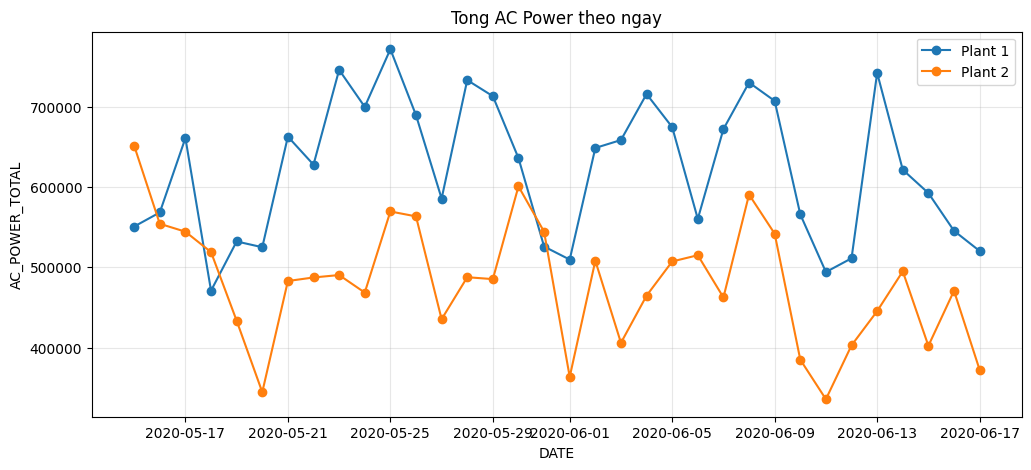

In [7]:
daily_generation = (
    generation.assign(DATE=generation['DATE_TIME'].dt.floor('D'))
    .groupby(['PLANT_NO', 'DATE'], as_index=False)
    .agg(AC_POWER_TOTAL=('AC_POWER', 'sum'), DC_POWER_TOTAL=('DC_POWER', 'sum'))
)

fig, ax = plt.subplots(figsize=(12, 5))
for plant_no, data in daily_generation.groupby('PLANT_NO'):
    ax.plot(data['DATE'], data['AC_POWER_TOTAL'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
ax.set_title('Tong AC Power theo ngay')
ax.set_xlabel('DATE')
ax.set_ylabel('AC_POWER_TOTAL')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

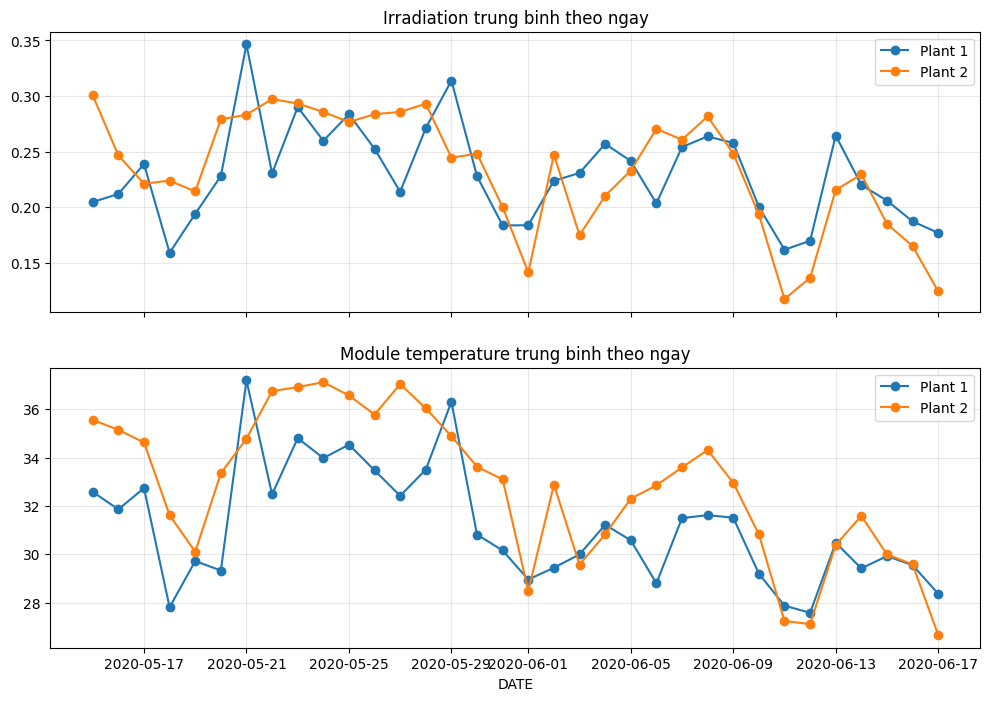

In [8]:
daily_weather = (
    weather_sensor.assign(DATE=weather_sensor['DATE_TIME'].dt.floor('D'))
    .groupby(['PLANT_NO', 'DATE'], as_index=False)
    .agg(
        IRRADIATION_MEAN=('IRRADIATION', 'mean'),
        AMBIENT_TEMPERATURE_MEAN=('AMBIENT_TEMPERATURE', 'mean'),
        MODULE_TEMPERATURE_MEAN=('MODULE_TEMPERATURE', 'mean'),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for plant_no, data in daily_weather.groupby('PLANT_NO'):
    axes[0].plot(data['DATE'], data['IRRADIATION_MEAN'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
    axes[1].plot(data['DATE'], data['MODULE_TEMPERATURE_MEAN'], marker='o', linewidth=1.5, label=f'Plant {plant_no}')
axes[0].set_title('Irradiation trung binh theo ngay')
axes[1].set_title('Module temperature trung binh theo ngay')
axes[1].set_xlabel('DATE')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

## 7. Tong hop generation ve cap plant/timestamp

Du lieu generation nam o cap inverter. De ghep voi weather sensor cua ca nha may, can tong hop cong suat theo `PLANT_ID`, `PLANT_NO`, `DATE_TIME` truoc.

In [9]:
generation_agg = aggregate_generation(generation)

display(generation_agg.head())
display(generation_agg.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), timestamps=('DATE_TIME', 'nunique')))

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,21,21,1.0
1,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,21,21,1.0
2,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,21,21,1.0
3,4135001,1,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,21,21,1.0
4,4135001,1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,22,22,1.0


,rows,timestamps
PLANT_NO,,
1,3158,3158
2,3259,3259


## 8. Doc du lieu Open-Meteo neu da chay `weather_api_fetcher.py`

In [10]:
def load_open_meteo_weather(plant_no: int) -> pd.DataFrame | None:
    path = API_WEATHER_DIR / f'open_meteo_weather_plant_{plant_no}.csv'
    if not path.exists():
        print(f'Chua co Open-Meteo CSV cho Plant {plant_no}: {path}')
        return None

    api_weather = pd.read_csv(path, parse_dates=['DATE_TIME'])
    api_weather['PLANT_NO'] = plant_no
    return api_weather


api_weather_frames = []
for plant_no in PLANTS:
    api_weather = load_open_meteo_weather(plant_no)
    if api_weather is not None:
        api_weather_frames.append(api_weather)

open_meteo_weather = pd.concat(api_weather_frames, ignore_index=True) if api_weather_frames else None
if open_meteo_weather is not None:
    display(open_meteo_weather.head())
    display(open_meteo_weather.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), timestamps=('DATE_TIME', 'nunique')))

,PLANT_NO,DATE_TIME,OM_TEMPERATURE_2M,OM_RELATIVE_HUMIDITY_2M,OM_DEW_POINT_2M,OM_APPARENT_TEMPERATURE,OM_PRESSURE_MSL,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION,LATITUDE,LONGITUDE,OPEN_METEO_TIMEZONE,OPEN_METEO_UTC_OFFSET_SECONDS
0,1,2020-05-15 00:00:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
1,1,2020-05-15 00:15:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
2,1,2020-05-15 00:30:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
3,1,2020-05-15 00:45:00,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800
4,1,2020-05-15 01:00:00,28.6,71,22.9,32.3,1006.5,970.6,0.0,8,11.8,117,0.0,0.0,0.0,0.0,0.0,14.815,78.287,Asia/Kolkata,19800


,rows,timestamps
PLANT_NO,,
1,3264,3264
2,3264,3264


## 9. Ghep noi du lieu hop li

In [11]:
weather_sensor_clean = weather_sensor.rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})

merged = generation_agg.merge(
    weather_sensor_clean,
    on=['PLANT_ID', 'PLANT_NO', 'DATE_TIME'],
    how='left',
    validate='one_to_one',
)

if open_meteo_weather is not None:
    api_cols_to_drop = [col for col in ['LATITUDE', 'LONGITUDE', 'OPEN_METEO_TIMEZONE', 'OPEN_METEO_UTC_OFFSET_SECONDS'] if col in open_meteo_weather.columns]
    api_merge = open_meteo_weather.drop(columns=api_cols_to_drop)
    merged = merged.merge(api_merge, on=['PLANT_NO', 'DATE_TIME'], how='left', validate='one_to_one')

merged = add_time_features(merged)
merged = merged.sort_values(['PLANT_NO', 'DATE_TIME']).reset_index(drop=True)

display(merged.head())
display(merged.groupby('PLANT_NO').agg(rows=('DATE_TIME', 'size'), missing_sensor_weather=('AMBIENT_TEMPERATURE', lambda s: int(s.isna().sum()))))

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,WEATHER_SENSOR_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,OM_TEMPERATURE_2M,OM_RELATIVE_HUMIDITY_2M,OM_DEW_POINT_2M,OM_APPARENT_TEMPERATURE,OM_PRESSURE_MSL,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION,HOUR,MINUTE,DAY,DAYOFWEEK,WEEKOFYEAR,MONTH,DAYOFYEAR,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,0,15,4,20,5,136,0.000000,1.000000,0
1,4135001,1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,15,15,4,20,5,136,0.065403,0.997859,0
2,4135001,1,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,30,15,4,20,5,136,0.130526,0.991445,0
3,4135001,1,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,21,21,1.0,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,29.5,67,22.8,32.7,1006.8,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0,0,45,15,4,20,5,136,0.195090,0.980785,0
4,4135001,1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,22,22,1.0,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,28.6,71,22.9,32.3,1006.5,970.6,0.0,8,11.8,117,0.0,0.0,0.0,0.0,0.0,1,0,15,4,20,5,136,0.258819,0.965926,0


,rows,missing_sensor_weather
PLANT_NO,,
1,3158,1
2,3259,0


## 10. Kiem tra chat luong du lieu sau merge

In [12]:
key_duplicates = merged.duplicated(['PLANT_ID', 'PLANT_NO', 'DATE_TIME']).sum()
print('Duplicate merged keys:', key_duplicates)

missing_after_merge = merged.isna().sum().sort_values(ascending=False).rename('missing').to_frame()
display(missing_after_merge[missing_after_merge['missing'] > 0])

numeric_cols = merged.select_dtypes(include='number').columns
display(merged[numeric_cols].describe().T)

Duplicate merged keys: 0


,missing
MODULE_TEMPERATURE,1
IRRADIATION,1
WEATHER_SENSOR_KEY,1
AMBIENT_TEMPERATURE,1


,count,mean,std,min,25%,50%,75%,max
PLANT_ID,6417.0,4.135509e+06,4.999770e+02,4.135001e+06,4.135001e+06,4.136001e+06,4.136001e+06,4.136001e+06
PLANT_NO,6417.0,1.507870e+00,4.999770e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
DC_POWER_TOTAL,6417.0,3.633706e+04,6.957760e+04,0.000000e+00,0.000000e+00,1.264839e+03,1.779019e+04,2.989378e+05
AC_POWER_TOTAL,6417.0,5.844489e+03,7.576456e+03,0.000000e+00,0.000000e+00,6.399071e+02,1.189813e+04,2.915021e+04
DAILY_YIELD_TOTAL,6417.0,7.008690e+04,5.778587e+04,0.000000e+00,1.060064e+04,7.159500e+04,1.206730e+05,1.937700e+05
TOTAL_YIELD_TOTAL,6417.0,7.026527e+09,6.825699e+09,0.000000e+00,1.536176e+08,9.712150e+09,1.419024e+10,1.419408e+10
ACTIVE_SOURCE_COUNT,6417.0,2.126788e+01,1.910910e+00,4.000000e+00,2.200000e+01,2.200000e+01,2.200000e+01,2.200000e+01
ZERO_AC_COUNT,6417.0,1.053654e+01,1.029451e+01,0.000000e+00,0.000000e+00,8.000000e+00,2.200000e+01,2.200000e+01
ZERO_AC_RATIO,6417.0,4.990312e-01,4.808296e-01,0.000000e+00,0.000000e+00,3.888889e-01,1.000000e+00,1.000000e+00
AMBIENT_TEMPERATURE,6416.0,2.683477e+01,3.934008e+00,2.039850e+01,2.367318e+01,2.597393e+01,2.936660e+01,3.918164e+01


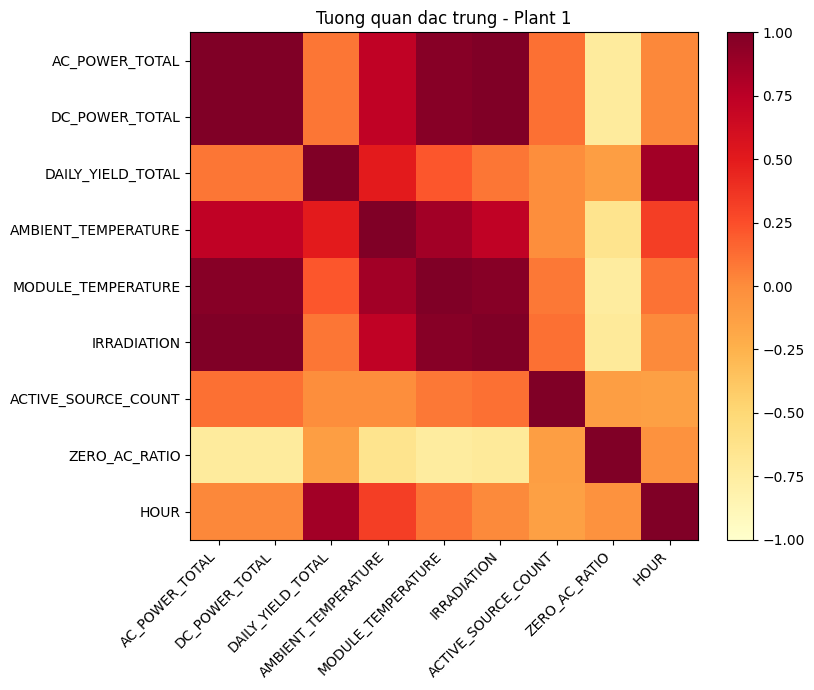

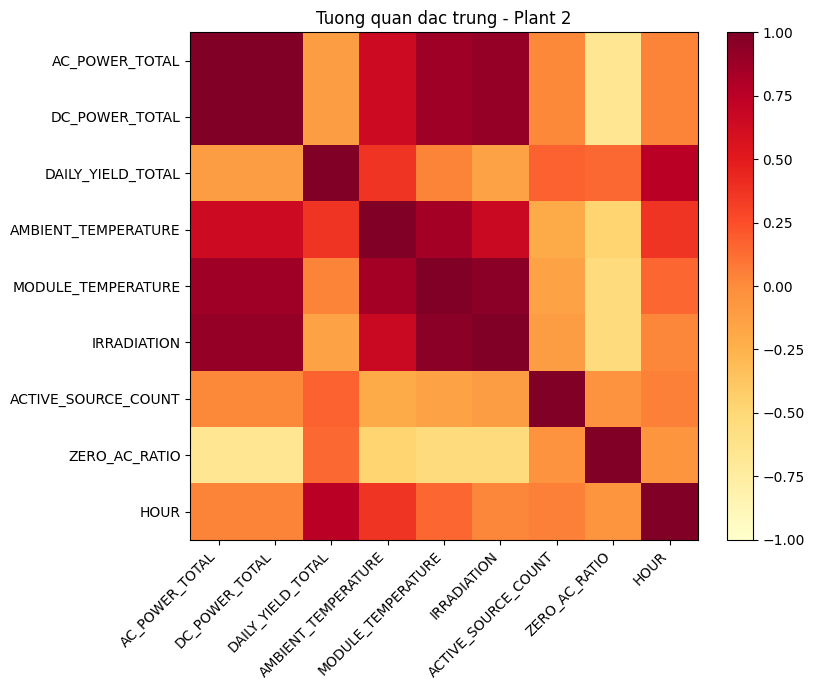

In [13]:
corr_cols = [
    'AC_POWER_TOTAL',
    'DC_POWER_TOTAL',
    'DAILY_YIELD_TOTAL',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'ACTIVE_SOURCE_COUNT',
    'ZERO_AC_RATIO',
    'HOUR',
]
corr_cols = [col for col in corr_cols if col in merged.columns]

for plant_no, data in merged.dropna(subset=['AMBIENT_TEMPERATURE', 'IRRADIATION']).groupby('PLANT_NO'):
    corr = data[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr.values, cmap='YlOrRd', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    ax.set_title(f'Tuong quan dac trung - Plant {plant_no}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

## 11. Luu du lieu da tien xu li cho cac buoc sau

File dau ra van chua train model. Day la du lieu plant-level da duoc lam sach va ghep weather hop li.

In [14]:
merged.to_csv(OUTPUT_DIR / 'eda_all_plants_merged.csv', index=False)

for plant_no, data in merged.groupby('PLANT_NO'):
    data.to_csv(OUTPUT_DIR / f'eda_plant_{plant_no}_merged.csv', index=False)

print('Da luu:')
print(OUTPUT_DIR / 'eda_all_plants_merged.csv')
for plant_no in PLANTS:
    print(OUTPUT_DIR / f'eda_plant_{plant_no}_merged.csv')

Da luu:
z:\DOCUMENTS\KPDL\Prj_gr13\outputs\eda_all_plants_merged.csv
z:\DOCUMENTS\KPDL\Prj_gr13\outputs\eda_plant_1_merged.csv
z:\DOCUMENTS\KPDL\Prj_gr13\outputs\eda_plant_2_merged.csv
